In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# 1. Setup Path (Assuming you need to access 'src/metrics.py' or data paths)
# Navigate up from Notebook to the project root: .../Bayesian_DA_Budyko_modeling/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(PROJECT_ROOT)

# Import metrics function (assuming it's in src/metrics.py)
from src.metrics import calculate_nse, calculate_kge

# --- Configuration (Adjust file paths based on where run_simulation.py saves data) ---

# Define the folder where your results (e.g., Q_simulated_df) are saved.
# Assuming results are saved in a 'results' folder at the project root.
RESULTS_FOLDER = os.path.join(PROJECT_ROOT, 'results')

# Define the filename for the saved simulated flow data.
# You MUST check your run_simulation.py script to see what it saved!
SIMULATED_Q_FILE = 'Q_simulated_all_scenarios.csv' 
OBSERVED_Q_FILE = 'Q_observed_usgs.csv' 
SPIN_UP_YEARS = 5
SPIN_UP_MONTHS = SPIN_UP_YEARS * 12

# --- 2. Load Data ---

try:
    # Load the combined simulation results (Q_simulated)
    Q_sim_df = pd.read_csv(os.path.join(RESULTS_FOLDER, SIMULATED_Q_FILE), index_col=0, parse_dates=True)
    
    # Load the original observed streamflow (Q_usgs)
    Q_obs_df = pd.read_csv(os.path.join(RESULTS_FOLDER, OBSERVED_Q_FILE), index_col=0, parse_dates=True)
    
    # The 'run_simulation.py' output showed a summary table, but we need the raw time series
    print(f"Successfully loaded simulation data from {SIMULATED_Q_FILE}")

except FileNotFoundError:
    print(f"FATAL: Could not find results files in {RESULTS_FOLDER}.")
    print("Please check the 'RESULTS_FOLDER' and file names.")
    # Exit or create empty dataframes to prevent further errors
    Q_sim_df = None
    Q_obs_df = None

if Q_sim_df is not None:
    
    # Identify the basins and scenarios
    BASIN_IDS = Q_obs_df.columns.tolist()
    SCENARIOS = ['Q_ke', 'Q_assim_base', 'Q_assim_Budyko']
    
    # --- 3. Re-calculate and Summarize Metrics (Post Spin-up) ---

    summary_metrics = {'Basin': BASIN_IDS}
    
    # Ensure the DataFrames are aligned by time (index) and cut off spin-up
    Q_obs_post_spinup = Q_obs_df.iloc[SPIN_UP_MONTHS:]
    Q_sim_post_spinup = Q_sim_df.iloc[SPIN_UP_MONTHS:]

    for scenario in SCENARIOS:
        nse_list = []
        kge_list = []
        
        for basin in BASIN_IDS:
            # Simulated data columns are named like '06452000_Q_ke'
            sim_col = f"{basin}_{scenario}" 
            
            # Extract the correct time series
            Q_sim = Q_sim_post_spinup[sim_col].values
            Q_obs = Q_obs_post_spinup[basin].values
            
            # Calculate metrics
            nse_list.append(calculate_nse(Q_obs, Q_sim))
            kge_list.append(calculate_kge(Q_obs, Q_sim))

        summary_metrics[f'{scenario}_NSE'] = nse_list
        summary_metrics[f'{scenario}_KGE'] = kge_list

    metrics_df = pd.DataFrame(summary_metrics).set_index('Basin')
    
    # print("\n--- Summary Performance (Recalculated) ---")
    # print(metrics_df)

    # --- 4. Visualization (Hydrographs) ---

    # Select one or two basins for detailed visualization
    # PLOT_BASINS = ['06452000', '02315500'] # One bad, one better (from previous output)
PLOT_BASINS = ['06452000', '13340000', '06447000', '06360500', '06354000', '05057000', '07301500', '06191500', '02315500', '06784000'] 

import proplot as pplt

# --- 4. Limit plotting period ---
start_date = '2013-01-12'
end_date = '2014-12-31'

Q_obs_df = Q_obs_df.loc[start_date:end_date]
Q_sim_df = Q_sim_df.loc[start_date:end_date]

import proplot as pplt

fig, axs = pplt.subplots(
    nrows=10,
    ncols=1,
    sharex=True,
    refwidth=8,
    refheight=3,
    facecolor='white'#, dpi=200
)

for i, (ax, basin_id) in enumerate(zip(axs, PLOT_BASINS)):
    ax.plot(Q_obs_df.index, Q_obs_df[basin_id],color='black', lw=1.5, label='USGS Observed ($Q_{obs}$)')
    ax.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_ke'] , color='grey', ls='--', lw=1.2, label='Base Model ($Q_{ke}$)')
    ax.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_assim_base'], color='orange', lw=1.2, label='Base Model')
    ax.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_assim_Budyko'], color='blue', lw=1.2, label='Budyko Model')

    ax.format(title=f'{basin_id}', grid=True, linewidth=0.6, fontsize=20)
    if i == 0:
        ax.legend(loc='ul', frame=False, ncols=1, fontsize=20)

fig.format(
    xlabel='Date',
    ylabel='Streamflow (mm/day)',
)
pplt.show()


FATAL: Could not find results files in c:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\results.
Please check the 'RESULTS_FOLDER' and file names.


AttributeError: 'NoneType' object has no attribute 'loc'

In [3]:
df  = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\02112120_enkf_timeseries_ET_DA.csv')#.columns
df.set_index('Date', inplace=True)
df

,P_input,PET_input,Q_USGS_obs,ET_NLDAS_obs,ET_Budyko,Q_Base_Q_sim,Q_Base_ET_sim,Q_Base_S_sim,Q_Base_G_sim,Q_B_Q_sim,Q_B_ET_sim,Q_B_S_sim,Q_B_G_sim,Q_ET_DA_Q_sim,Q_ET_DA_ET_sim,Q_ET_DA_S_sim,Q_ET_DA_G_sim
Date,,,,,,,,,,,,,,,,,
2000-01-01,54.682990,0.099795,25.576420,16.577007,0.091663,14.099131,0.085617,482.401737,92.489738,13.623641,0.091663,486.183693,90.284507,14.057761,0.085900,488.121016,87.066247
2000-02-01,48.647198,0.111818,28.734565,19.702500,0.101940,16.855542,0.095932,490.294296,116.275493,16.198798,0.101940,495.477853,113.332849,16.375610,0.096146,499.535002,107.814015
2000-03-01,85.960686,0.206211,34.967346,29.700602,0.187720,19.321028,0.176915,534.312515,138.702609,18.505182,0.187720,540.821095,135.253434,18.407241,0.177118,546.987759,127.704924
2000-04-01,130.447540,0.198296,36.037775,45.937004,0.183138,22.037951,0.170124,618.037627,163.199553,21.065575,0.183138,625.945785,159.323615,20.624443,0.170154,634.477450,149.798001
2000-05-01,39.969406,0.323058,21.454130,82.109130,0.278747,23.896738,0.277161,614.392249,182.623028,22.808174,0.278747,623.488050,178.659877,21.912637,0.276967,634.417396,167.363078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-01,206.690380,0.244754,38.467118,104.758606,0.227611,107.203838,0.209982,1114.575619,931.633794,104.843763,0.227611,1132.426523,1000.034362,95.091923,0.201959,1081.141906,628.796756
2014-09-01,63.872776,0.184107,26.555749,70.556946,0.166502,77.761794,0.157951,1090.743905,930.743684,75.775692,0.166502,1108.678070,999.256817,40.449395,0.151932,1081.339876,624.943502
2014-10-01,101.559980,0.180471,21.760133,48.050400,0.165902,84.371602,0.154832,1090.087982,929.907961,82.288135,0.165902,1107.821285,998.532328,53.891805,0.148941,1081.426233,624.684670


In [ ]:
'Q_USGS_obs', 'Q_Base_Q_sim', 'Q_Base_ET_sim','Q_B_Q_sim', 'Q_B_ET_sim', 'Q_ET_DA_Q_sim','Q_ET_DA_ET_sim'

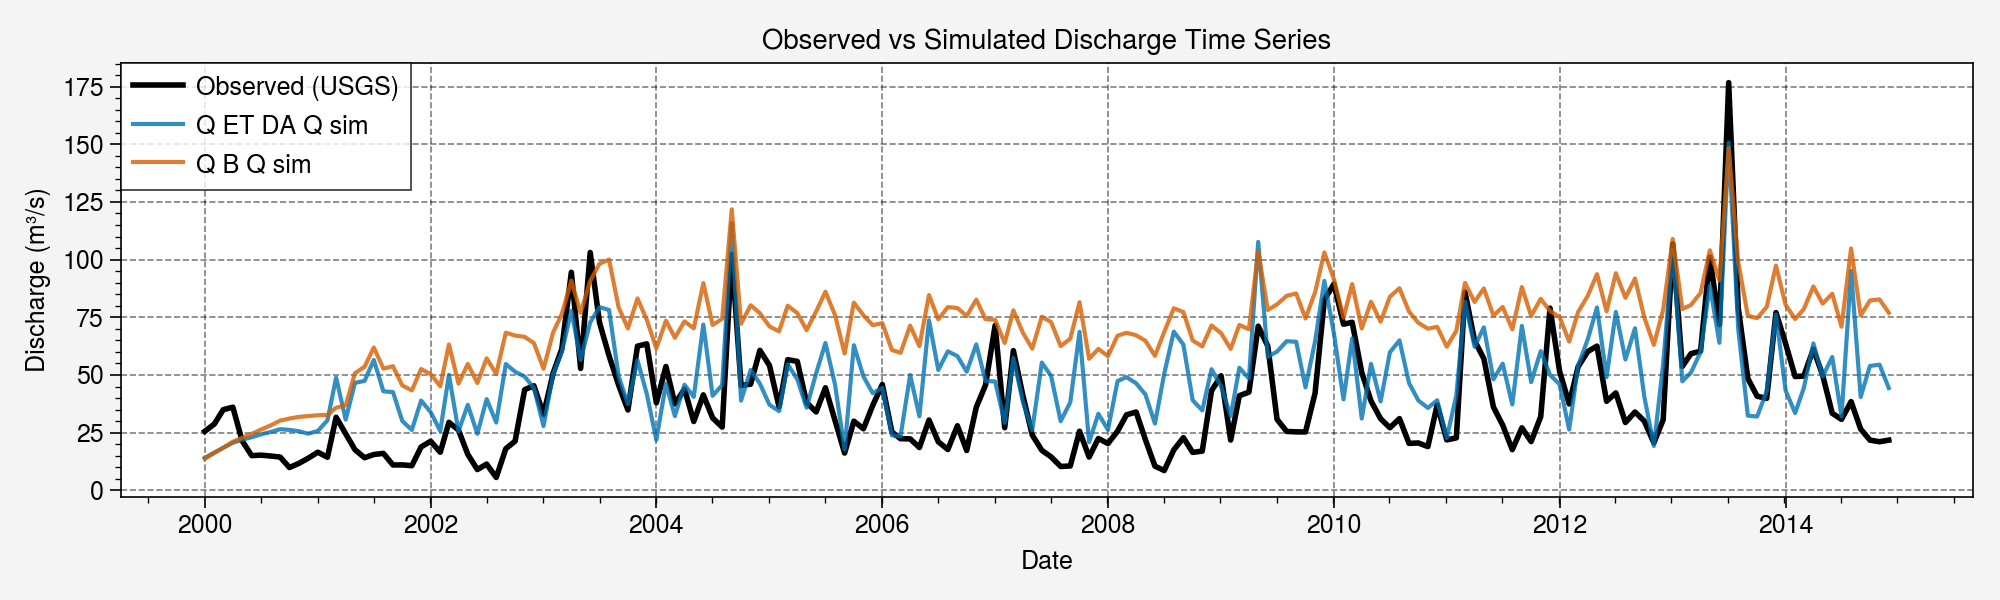

In [5]:
import matplotlib.pyplot as plt

# --- Ensure Date is a datetime index ---
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# --- Define observed and simulated columns ---
obs_col = 'Q_USGS_obs'
sim_cols = [ 'Q_ET_DA_Q_sim', 'Q_B_Q_sim']

# --- Plot observed vs simulated discharge ---
plt.figure(figsize=(10, 3))
plt.plot(df.index, df[obs_col], label='Observed (USGS)', color='black', linewidth=2)

for sim in sim_cols:
    plt.plot(df.index, df[sim], label=sim.replace('_', ' '), alpha=0.8)

plt.title('Observed vs Simulated Discharge Time Series')
plt.xlabel('Date')
plt.ylabel('Discharge (m³/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [142]:
# In run_simulation.py, before the main basin loop
import sys
import pandas as pd

NLDAS_FILE = r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\data\processed\extracted_nldas_data.feather'

try:
    # Use 'pyarrow' engine for feather files
    df_nldas_all = pd.read_feather(NLDAS_FILE)
    print("✅ Successfully loaded all NLDAS data from .feather file.")
    # Assuming df_nldas_all has columns like ['gauge_id', 'Date', 'P_input', 'PET_input', 'ET_NLDAS_obs']
except Exception as e:
    print(f"❌ FATAL: Could not load NLDAS data from {NLDAS_FILE}. Error: {e}")
    sys.exit(1)  # Stop simulation if data cannot be loaded


✅ Successfully loaded all NLDAS data from .feather file.


In [143]:
# In run_simulation.py, INSIDE the main basin loop (e.g., around the start of the simulation)

# --- 1. Filter NLDAS Data ---
# CRITICAL: Ensure 'gauge_id' column type matches basin_id type (usually string)
df_nldas_basin = df_nldas_all[df_nldas_all['gauge_id'] == basin_id].copy()

if df_nldas_basin.empty:
    print(f"⚠️ Skipping {basin_id}: No matching NLDAS data found in the .feather file.")
    continue

# --- 2. Prepare for Merge ---
# Set 'Date' as index for both (Q_USGS data is likely already indexed by Date)
df_nldas_basin.set_index('Date', inplace=True) 

# --- 3. Merge with Q_USGS Data ---
# Assuming 'df_q_data' is the DataFrame containing 'Q_USGS_obs'
# The result should be your 'df_data' used for simulation
df_data = pd.merge(
    df_q_data[['Q_USGS_obs']], # Observation data, already loaded
    df_nldas_basin[['P_input', 'PET_input', 'ET_NLDAS_obs']],
    left_index=True,
    right_index=True,
    how='outer' # Use 'outer' or 'inner' depending on required data length
)

# 🔥 DEBUG CHECK: Print the first few P and PET values
print(f"DEBUG: {basin_id} P_input start values: {df_data['P_input'].head(5).tolist()}")

# --- Proceed to Simulation (Model runs using df_data) ---

KeyError: 'gauge_id'

<AxesSubplot:xlabel='Date'>

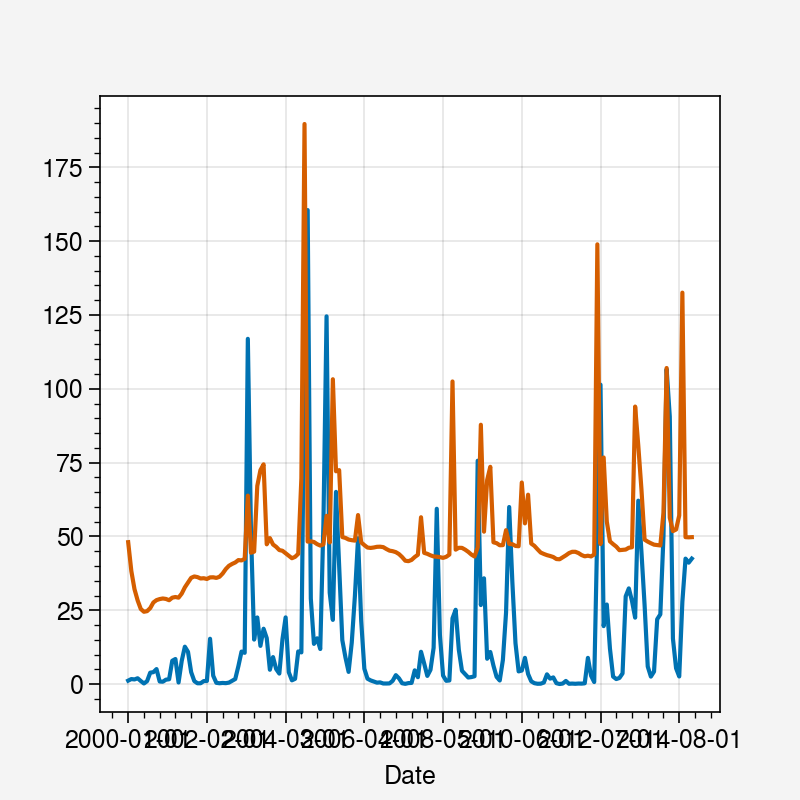

In [75]:
df['Q_USGS_obs'].plot()
(df['Q_Base_Q_sim']*0.5).plot()

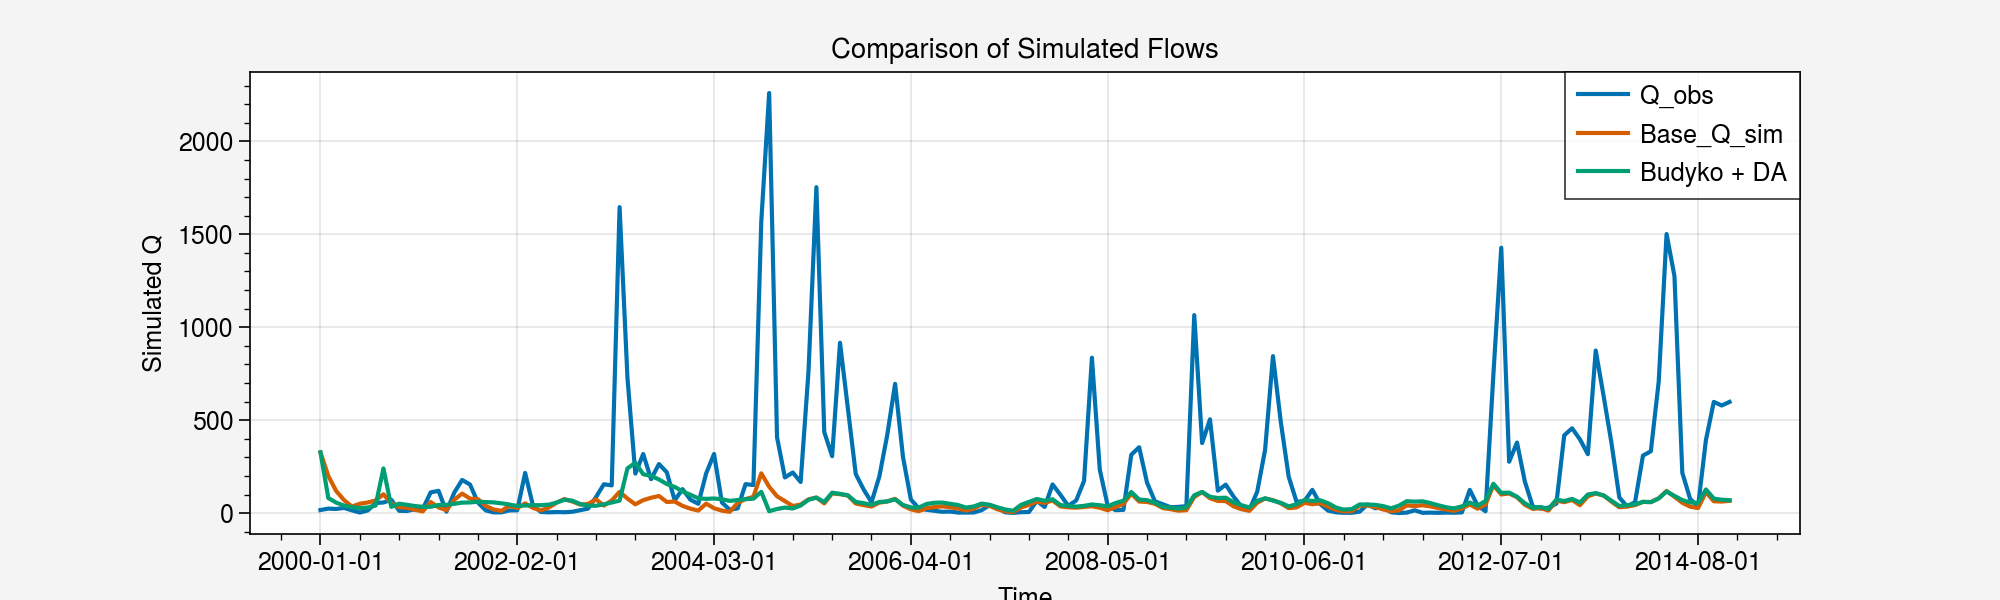

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
df['Q_obs'].plot(label='Q_obs')
df['Base_Q_sim'].plot(label='Base_Q_sim')

df['Budyko+DA_Q_sim'].plot(label='Budyko + DA')
plt.xlabel('Time')
plt.ylabel('Simulated Q')
plt.title('Comparison of Simulated Flows')
plt.legend()
plt.show()


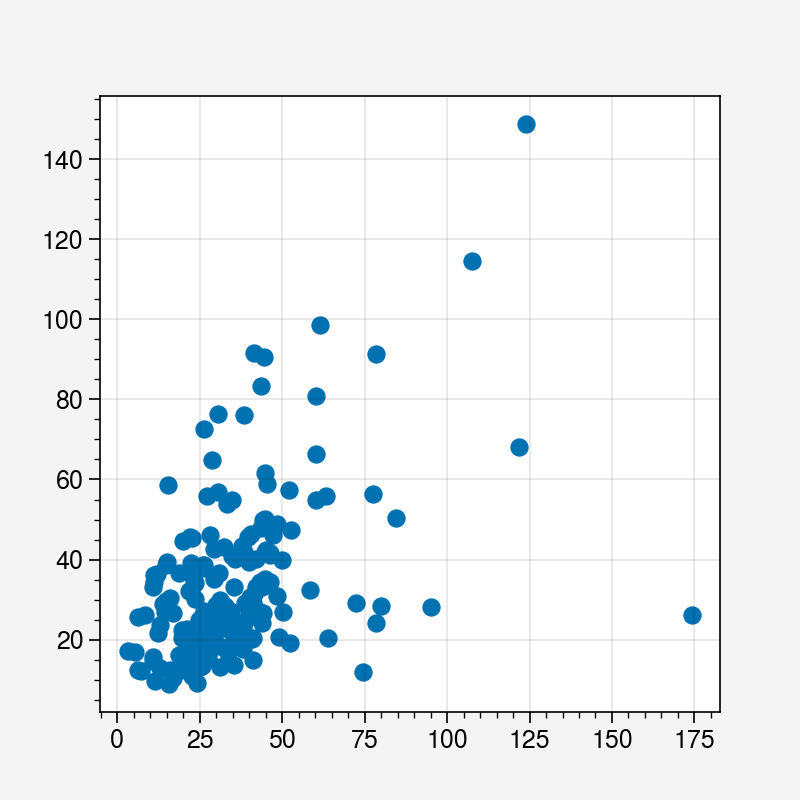

In [50]:
plt.scatter(df['Q_obs'], df['Budyko+DA_Q_sim'])

<AxesSubplot:xlabel='Date'>

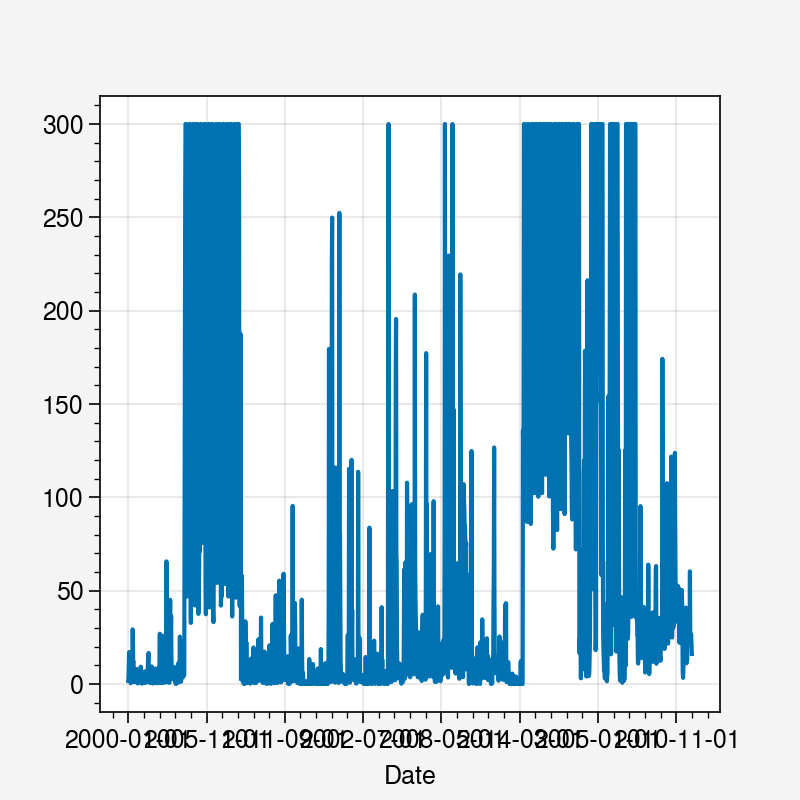

In [11]:
# df['Budyko+DA_Q_sim'].plot()
df['Q_obs'].plot()

In [1]:
import pandas as pd

In [5]:
simulated_components_02315500 = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\results\time_series_by_basin\02315500_simulated_components.csv')

<Axes: >

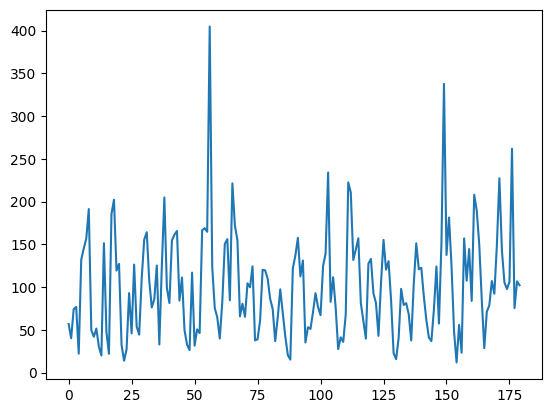

In [7]:
simulated_components_02315500['Q_assim_base'].plot()